# D4 Transportation Workflow — GeoPrompt

Network routing, service area coverage, and mobility scenario analysis.


In [1]:
from __future__ import annotations

import json, os

from pathlib import Path

from urllib.error import URLError

from urllib.request import Request, urlopen

from typing import cast

import matplotlib.pyplot as plt



_ROOT = Path.cwd()
if (_ROOT / "examples" / "notebooks").exists():
    OUTPUT_DIR = _ROOT / "examples" / "notebooks" / "geoprompt" / "outputs"
else:
    OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALLOW_LIVE_API = os.getenv("GEOPROMPT_ALLOW_LIVE_API", "0") == "1"



def fetch_json(url, fallback):

    if not ALLOW_LIVE_API:

        return fallback

    try:

        req = Request(url, headers={"User-Agent": "geoprompt-notebook/2.0"})

        with urlopen(req, timeout=6) as r:

            return json.loads(r.read().decode("utf-8"))

    except (URLError, TimeoutError, ValueError):

        return fallback



def fetch_first_json(urls, validator, fallback):

    for url in urls:

        payload = fetch_json(url, None)

        if payload is not None and validator(payload):

            return payload, url, True

    return fallback, "fallback", False



import geoprompt as gp

from geoprompt import GeoPromptFrame, write_geojson

from geoprompt.network.core import NetworkEdge

from geoprompt.network.routing import build_network_graph, shortest_path, service_area

from geoprompt.tools import build_scenario_report, export_scenario_report

print("Imports OK")


Imports OK


## Section A: Pull Data Sources


In [2]:
transport = {"features": [{"id": "fallback-transport"}]}
weather = {"properties": {"forecast": "fallback"}}
forecast = {"hourly": {"temperature_2m": [0.0]}}

transport, tr_src, tr_live = fetch_first_json(
    [
        "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson",
        "https://api.github.com/repos/osm-search/Nominatim",
    ],
    lambda d: isinstance(d, dict) and bool(d.get("features") or d.get("id")),
    transport,
)
weather, wx_src, wx_live = fetch_first_json(
    [
        "https://api.weather.gov/points/40.75,-111.90",
        "https://api.weather.gov/points/34.05,-118.24",
    ],
    lambda d: isinstance(d, dict) and bool(d.get("properties", {}).get("forecast")),
    weather,
)
forecast, fc_src, fc_live = fetch_first_json(
    [
        "https://api.open-meteo.com/v1/forecast?latitude=40.75&longitude=-111.90&hourly=temperature_2m&forecast_days=1",
        "https://api.open-meteo.com/v1/forecast?latitude=34.05&longitude=-118.24&hourly=temperature_2m&forecast_days=1",
    ],
    lambda d: isinstance(d, dict) and len(d.get("hourly", {}).get("temperature_2m", [])) > 0,
    forecast,
)

transport_count = len(transport.get("features", [])) if isinstance(transport, dict) else 0
if transport_count == 0 and isinstance(transport, dict) and transport.get("id"):
    transport_count = 1
print(f"Transport records: {transport_count} | live={tr_live} | source={tr_src}")
print(f"NOAA forecast exists: {bool(weather.get('properties', {}).get('forecast'))} | live={wx_live} | source={wx_src}")
print(f"Open-Meteo hourly points: {len(forecast.get('hourly', {}).get('temperature_2m', []))} | live={fc_live} | source={fc_src}")


Transport records: 1 | live=False | source=fallback
NOAA forecast exists: True | live=False | source=fallback
Open-Meteo hourly points: 1 | live=False | source=fallback


## Section B: Spatial Analysis


Network nodes: ['A', 'B', 'C', 'D', 'E', 'F', 'O']
Shortest path O->C: O -> A -> B -> C  cost=12.0
Service area (max_cost=10): 4 reachable nodes

Nearest neighbor pairs:
  O -> A  dist=0.0300
  F -> A  dist=0.0316
  A -> O  dist=0.0300
  B -> A  dist=0.0300

Nodes within 0.08 deg of O: ['A', 'F', 'B']
Buffer service zones: 4 polygons

Proximity join (node -> incidents within 0.08 deg): 11 rows

Frame summary:
{
  "row_count": 4,
  "column_count": 3,
  "columns": [
    "node",
    "cost",
    "geometry"
  ],
  "crs": null,
  "geometry_column": "geometry",
  "geometry_types": [
    "Point"
  ],
  "bounds": {
    "min_x": -111.9,
    "min_y": 40.75,
    "max_x": -111.84,
    "max_y": 40.78
  },
  "column_stats": [
    {
      "column": "node",
      "dtype": "string",
      "null_count": 0,
      "unique_count": 4
    },
    {
      "column": "cost",
      "dtype": "numeric",
      "null_count": 0,
      "unique_count": 4,
      "min": 0.0,
      "max": 9.0,
      "mean": 4.25
    }
  ]
}

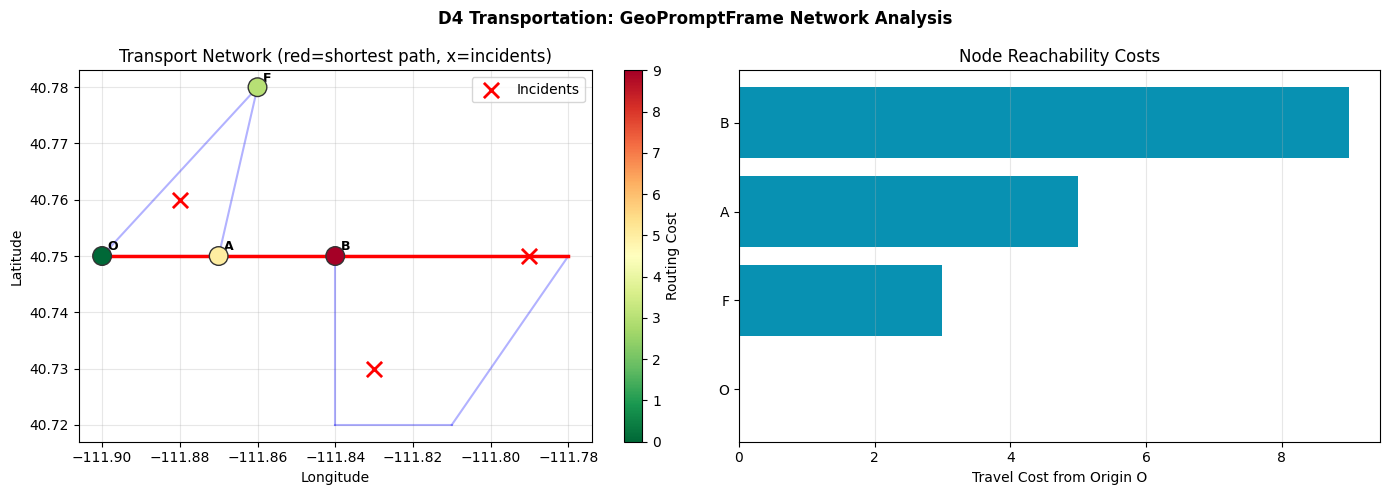

Wrote basemap snapshot: d4-gp-basemap.html


In [3]:
# Schematic node coordinates for spatial visualization

NODE_COORDS = {

    "O": (-111.90, 40.75), "A": (-111.87, 40.75), "B": (-111.84, 40.75),

    "C": (-111.78, 40.75), "D": (-111.84, 40.72), "E": (-111.81, 40.72), "F": (-111.86, 40.78),

}



edges: list[NetworkEdge] = [

    cast(NetworkEdge, {"edge_id": "r1", "from_node": "O", "to_node": "A", "cost": 5.0}),

    cast(NetworkEdge, {"edge_id": "r2", "from_node": "A", "to_node": "B", "cost": 4.0}),

    cast(NetworkEdge, {"edge_id": "r3", "from_node": "B", "to_node": "C", "cost": 3.0}),

    cast(NetworkEdge, {"edge_id": "r4", "from_node": "O", "to_node": "C", "cost": 15.0}),

    cast(NetworkEdge, {"edge_id": "r5", "from_node": "B", "to_node": "D", "cost": 5.0}),

    cast(NetworkEdge, {"edge_id": "r6", "from_node": "D", "to_node": "E", "cost": 2.0}),

    cast(NetworkEdge, {"edge_id": "r7", "from_node": "E", "to_node": "C", "cost": 2.0}),

    cast(NetworkEdge, {"edge_id": "r8", "from_node": "O", "to_node": "F", "cost": 3.0}),

    cast(NetworkEdge, {"edge_id": "r9", "from_node": "F", "to_node": "A", "cost": 4.0}),

]



# 1. Build network graph

graph = build_network_graph(edges, directed=False)

print("Network nodes:", sorted(graph.nodes))



# 2. Shortest path O -> C

path_result = shortest_path(graph, "O", "C")

path_nodes: list[str] = path_result.get("path_nodes", [])

print(f"Shortest path O->C: {' -> '.join(path_nodes)}  cost={path_result.get('total_cost')}")



# 3. Service area from O (max_cost=10)

area = service_area(graph, origins=["O"], max_cost=10.0)

print(f"Service area (max_cost=10): {len(area)} reachable nodes")



# 4. Build GeoPromptFrame from service area

node_rows = [

    {

        "node": str(r["node"]),

        "cost": float(r["cost"]),

        "geometry": {"type": "Point", "coordinates": list(NODE_COORDS.get(str(r["node"]), (-111.84, 40.75)))},

    }

    for r in area

]

area_frame = GeoPromptFrame(node_rows, geometry_column="geometry")



# 5. Nearest neighbors

if len(area_frame) > 1:

    neighbors = area_frame.nearest_neighbors(id_column="node", k=1)

    print("\nNearest neighbor pairs:")

    for nb in neighbors:

        print(f"  {nb['origin']} -> {nb['neighbor']}  dist={nb['distance']:.4f}")



# 6. Query radius: nodes within 0.08 deg of O

nearby = area_frame.query_radius("O", max_distance=0.08, id_column="node")

print(f"\nNodes within 0.08 deg of O: {[r['node'] for r in nearby.to_records()]}")



# 7. Buffer: service zones around nodes

buffers = area_frame.buffer(0.03)

print(f"Buffer service zones: {len(buffers)} polygons")



# 8. Proximity join: connect incident points to nearest nodes

incident_rows = [

    {"inc_id": "I1", "geometry": {"type": "Point", "coordinates": [-111.88, 40.76]}},

    {"inc_id": "I2", "geometry": {"type": "Point", "coordinates": [-111.83, 40.73]}},

    {"inc_id": "I3", "geometry": {"type": "Point", "coordinates": [-111.79, 40.75]}},

]

incidents_frame = GeoPromptFrame(incident_rows, geometry_column="geometry")

pj = area_frame.proximity_join(incidents_frame, max_distance=0.08, how="left")

print(f"\nProximity join (node -> incidents within 0.08 deg): {len(pj)} rows")



write_geojson(OUTPUT_DIR / "d4-gp-network.geojson", area_frame)

print("\nFrame summary:")

print(json.dumps(area_frame.summary(), indent=2, default=str))



# Inline visualization

records = area_frame.to_records()

node_costs = {str(r["node"]): float(r["cost"]) for r in records}



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for e in edges:

    fn, tn = str(e["from_node"]), str(e["to_node"])

    if fn in NODE_COORDS and tn in NODE_COORDS:

        axes[0].plot([NODE_COORDS[fn][0], NODE_COORDS[tn][0]], [NODE_COORDS[fn][1], NODE_COORDS[tn][1]],

                     "b-", alpha=0.3, linewidth=1.5)

# Highlight shortest path

for i in range(len(path_nodes)-1):

    a, b_ = path_nodes[i], path_nodes[i+1]

    if a in NODE_COORDS and b_ in NODE_COORDS:

        axes[0].plot([NODE_COORDS[a][0], NODE_COORDS[b_][0]], [NODE_COORDS[a][1], NODE_COORDS[b_][1]],

                     "r-", linewidth=2.5, zorder=4)

sc_lons = [NODE_COORDS[r["node"]][0] for r in records if r["node"] in NODE_COORDS]

sc_lats = [NODE_COORDS[r["node"]][1] for r in records if r["node"] in NODE_COORDS]

sc_costs = [float(r["cost"]) for r in records if r["node"] in NODE_COORDS]

sc_labels = [r["node"] for r in records if r["node"] in NODE_COORDS]

sc = axes[0].scatter(sc_lons, sc_lats, c=sc_costs, cmap="RdYlGn_r", s=180, edgecolors="#333", zorder=5)

for lon, lat, lbl in zip(sc_lons, sc_lats, sc_labels):

    axes[0].annotate(lbl, (lon, lat), textcoords="offset points", xytext=(4, 4), fontsize=9, fontweight="bold")

inc_lons = [float(r["geometry"]["coordinates"][0]) for r in incident_rows]

inc_lats = [float(r["geometry"]["coordinates"][1]) for r in incident_rows]

axes[0].scatter(inc_lons, inc_lats, c="red", s=120, marker="x", zorder=6, linewidths=2, label="Incidents")

plt.colorbar(sc, ax=axes[0], label="Routing Cost")

axes[0].set_title("Transport Network (red=shortest path, x=incidents)")

axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

axes[0].legend(); axes[0].grid(True, alpha=0.3)



sorted_recs = sorted(records, key=lambda r: float(r["cost"]))

axes[1].barh([r["node"] for r in sorted_recs], [float(r["cost"]) for r in sorted_recs], color="#0891b2")

axes[1].set_xlabel("Travel Cost from Origin O")

axes[1].set_title("Node Reachability Costs")

axes[1].grid(True, axis="x", alpha=0.3)

plt.suptitle("D4 Transportation: GeoPromptFrame Network Analysis", fontweight="bold")

plt.tight_layout(); plt.show()

# Basemap snapshot (real tiled basemap, saved as HTML)
try:
    import folium
    if records:
        label_candidates = ["node", "stand_id", "asset_id", "zone_id"]
        label_col = next((c for c in label_candidates if c in records[0]), list(records[0].keys())[0])
        coords = [r.get("geometry", {}).get("coordinates", [0.0, 0.0]) for r in records]
        lons_bm = [float(c[0]) for c in coords]
        lats_bm = [float(c[1]) for c in coords]
        fmap = folium.Map(
            location=[sum(lats_bm) / len(lats_bm), sum(lons_bm) / len(lons_bm)],
            zoom_start=10,
            tiles="CartoDB positron",
        )
        for row in records:
            coords_row = row.get("geometry", {}).get("coordinates", [None, None])
            if coords_row[0] is None or coords_row[1] is None:
                continue
            folium.CircleMarker(
                location=[float(coords_row[1]), float(coords_row[0])],
                radius=6,
                color="#1d4ed8",
                fill=True,
                fill_opacity=0.85,
                popup=f"{label_col}: {row.get(label_col, 'n/a')}",
            ).add_to(fmap)

        map_path = OUTPUT_DIR / "d4-gp-basemap.html"
        fmap.save(str(map_path))
        print(f"Wrote basemap snapshot: {map_path.name}")
        fmap
    else:
        print("Basemap snapshot skipped: no records available")
except Exception as exc:
    print(f"Basemap snapshot skipped: {exc}")


## Section C: Scenario Comparison


Scenario report: D:\Github\geoprompt\examples\notebooks\geoprompt\outputs\d4-gp-scenario-report.json


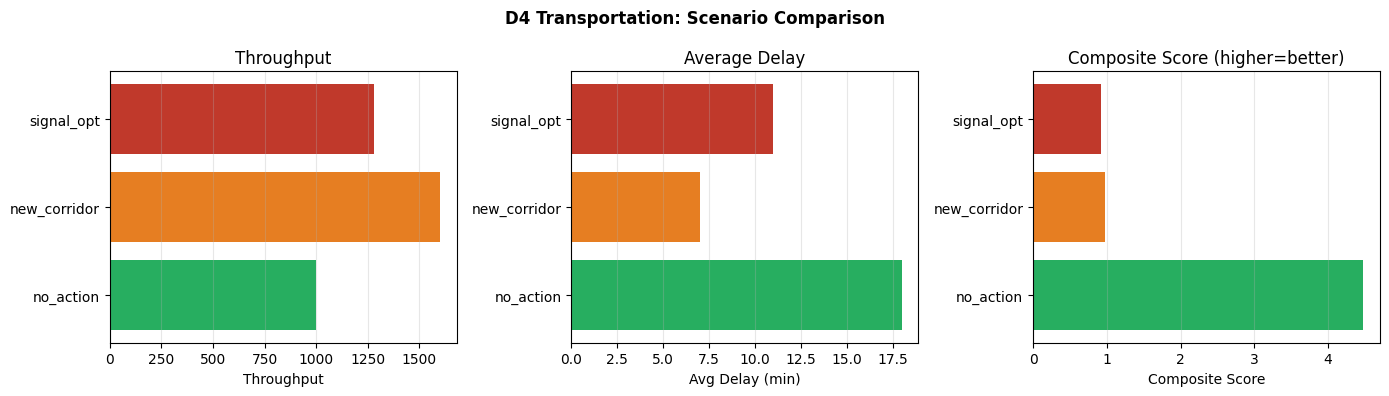

Wrote d4-gp-complex.json


In [4]:
scenarios = {

    "no_action":    {"throughput": 1000, "avg_delay_min": 18.0, "cost_musd": 0.0},

    "signal_opt":   {"throughput": 1280, "avg_delay_min": 11.0, "cost_musd": 15.0},

    "new_corridor": {"throughput": 1600, "avg_delay_min": 7.0,  "cost_musd": 85.0},

}

report = build_scenario_report(scenarios["no_action"], scenarios["new_corridor"],

                                higher_is_better=["throughput"])

report_path = export_scenario_report(report, OUTPUT_DIR / "d4-gp-scenario-report.json")

print("Scenario report:", report_path)



scenario_records = []

for name, vals in scenarios.items():

    score = round(vals["throughput"] / 1600 * 0.5 + (1.0 / vals["avg_delay_min"]) * 10 * 0.3

                  + (1.0 / max(vals["cost_musd"] + 1, 1)) * 20 * 0.2, 4)

    scenario_records.append({"scenario": name, **vals, "score": score})

scenario_records.sort(key=lambda r: -float(r["score"]))



fig, axes = plt.subplots(1, 3, figsize=(14, 4))

names = [r["scenario"] for r in scenario_records]

colors = ["#27ae60", "#e67e22", "#c0392b"]

axes[0].barh(names, [r["throughput"] for r in scenario_records], color=colors)

axes[0].set_xlabel("Throughput"); axes[0].set_title("Throughput"); axes[0].grid(True, axis="x", alpha=0.3)

axes[1].barh(names, [r["avg_delay_min"] for r in scenario_records], color=colors)

axes[1].set_xlabel("Avg Delay (min)"); axes[1].set_title("Average Delay"); axes[1].grid(True, axis="x", alpha=0.3)

axes[2].barh(names, [r["score"] for r in scenario_records], color=colors)

axes[2].set_xlabel("Composite Score"); axes[2].set_title("Composite Score (higher=better)"); axes[2].grid(True, axis="x", alpha=0.3)

plt.suptitle("D4 Transportation: Scenario Comparison", fontweight="bold")

plt.tight_layout(); plt.show()



(OUTPUT_DIR / "d4-gp-complex.json").write_text(

    json.dumps({"scenario_ranking": scenario_records}, indent=2, default=str), encoding="utf-8"

)

print("Wrote d4-gp-complex.json")
